## 1.Import necessary Libraries

In [84]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from sklearn.datasets import load_wine

import warnings
warnings.filterwarnings("ignore")

## 2.Import DataSet

In [85]:
wine_data = load_wine()

In [86]:
wine_data_df = pd.DataFrame(wine_data.data,columns=wine_data.feature_names)
wine_data_df["torget"] = wine_data.target
wine_data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,torget
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


## 3.Data Undersanding 

In [87]:
wine_data_df.shape

(178, 14)

In [88]:
wine_data_df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
torget                          0
dtype: int64

In [89]:
wine_data_df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
torget                            int64
dtype: object

## 4.Data Preppuration

### 4.1 Data Transformation

In [90]:
X = wine_data_df.drop("torget",axis=1)
y = wine_data_df["torget"]

## 5.Model Buolding || 6.Model Training || 7.Model Testing

In [92]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=46,shuffle=True,stratify=y)

In [93]:
x_train.shape,y_train.shape

((142, 13), (142,))

In [94]:
x_test.shape,y_test.shape

((36, 13), (36,))

## Not Standardscaler use

#### N_estimator = 3

In [95]:
knn_model = KNeighborsClassifier( n_neighbors=3)
knn_model.fit(x_train,y_train)
y_pred_train = knn_model.predict(x_train)
print("Accuracy_score:",round(accuracy_score(y_train,y_pred_train),4))

Accuracy_score: 0.8451


#### N_estimator = 5

In [96]:
knn_model = KNeighborsClassifier( n_neighbors=5)
knn_model.fit(x_train,y_train)
y_pred_train = knn_model.predict(x_train)
print("Accuracy_score:",round(accuracy_score(y_train,y_pred_train),4))

Accuracy_score: 0.7746


#### N_estimator = 7

In [99]:
knn_model = KNeighborsClassifier( n_neighbors=7)
knn_model.fit(x_train,y_train)
y_pred_train = knn_model.predict(x_train)
print("Accuracy_score:",round(accuracy_score(y_train,y_pred_train),4))

Accuracy_score: 0.7817


#### N_estimator = 9

In [100]:
knn_model = KNeighborsClassifier( n_neighbors=9)
knn_model.fit(x_train,y_train)
y_pred_train = knn_model.predict(x_train)
print("Accuracy_score:",round(accuracy_score(y_train,y_pred_train),4))

Accuracy_score: 0.7817


### Let's apply STANDARDIZATION Technique

In [101]:
st_scalar = StandardScaler() #This is very inportend for the KNN
scaled_x = st_scalar.fit_transform(X)
scaled_x

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [102]:
x_train,x_test,y_train,y_test = train_test_split(scaled_x,y,test_size=0.20,random_state=46,shuffle=True,stratify=y)

In [103]:
x_train.shape,y_train.shape

((142, 13), (142,))

In [104]:
x_test.shape,y_test.shape

((36, 13), (36,))

#### N_estimator = 3

In [105]:
knn_model = KNeighborsClassifier( n_neighbors=3)
knn_model.fit(x_train,y_train)
y_pred_train = knn_model.predict(x_train)
print("Accuracy_score:",round(accuracy_score(y_train,y_pred_train),4))

Accuracy_score: 0.9718


#### N_estimator = 5

In [106]:
knn_model = KNeighborsClassifier( n_neighbors=5)
knn_model.fit(x_train,y_train)
y_pred_train = knn_model.predict(x_train)
print("Accuracy_score:",round(accuracy_score(y_train,y_pred_train),4))

Accuracy_score: 0.993


#### N_estimator = 7

In [108]:
knn_model = KNeighborsClassifier( n_neighbors=7)
knn_model.fit(x_train,y_train)
y_pred_train = knn_model.predict(x_train)
print("Accuracy_score:",round(accuracy_score(y_train,y_pred_train),4))

Accuracy_score: 0.9718


#### N_estimator = 9

In [109]:
knn_model = KNeighborsClassifier( n_neighbors=9)
knn_model.fit(x_train,y_train)
y_pred_train = knn_model.predict(x_train)
print("Accuracy_score:",round(accuracy_score(y_train,y_pred_train),4))

Accuracy_score: 0.9718


# How to choose the Optimal no.of neighbours?

In [110]:
from sklearn.model_selection import KFold,cross_val_score

In [111]:
cv_matrics = KFold(n_splits=5,shuffle=True, random_state=46)

cross_validation_mean = []

for i in range (3,51,2):
    knn_model_classifier = KNeighborsClassifier(n_neighbors=i)
    knn_model_classifier.fit(scaled_x,y)
    cv_score = cross_val_score(estimator = knn_model_classifier,X = scaled_x,y = y,cv= cv_matrics)
    cross_validation_mean.append(cv_score.mean())
    
print(cross_validation_mean)

[np.float64(0.9550793650793651), np.float64(0.9606349206349206), np.float64(0.9776190476190477), np.float64(0.9550793650793651), np.float64(0.9663492063492063), np.float64(0.9609523809523809), np.float64(0.9663492063492063), np.float64(0.9607936507936508), np.float64(0.9550793650793651), np.float64(0.9552380952380952), np.float64(0.9607936507936508), np.float64(0.9663492063492063), np.float64(0.9663492063492063), np.float64(0.972063492063492), np.float64(0.9776190476190477), np.float64(0.9776190476190477), np.float64(0.9661904761904763), np.float64(0.9550793650793651), np.float64(0.9663492063492063), np.float64(0.9606349206349206), np.float64(0.9606349206349206), np.float64(0.9607936507936508), np.float64(0.9550793650793651), np.float64(0.9550793650793651)]


In [112]:
max(cross_validation_mean)

np.float64(0.9776190476190477)

In [113]:
cross_validation_mean.index(max(cross_validation_mean))

2

## Let's visualize this 

In [114]:
import matplotlib.pyplot as plt

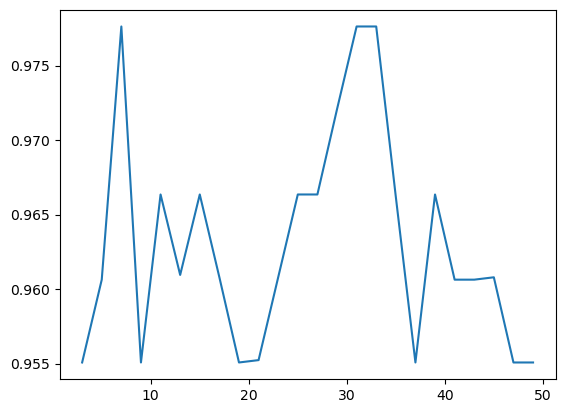

In [115]:
plt.plot(range(3,51,2),cross_validation_mean)

In [ ]:
1 = 3
2 = 5 #---> This is consider for i for n_neighbors

In [117]:
knn_model = KNeighborsClassifier( n_neighbors=2)
knn_model.fit(scaled_x,y)
y_pred = knn_model.predict(scaled_x)
print("Accuracy_score:",round(accuracy_score(y,y_pred),4))

Accuracy_score: 0.9719


# THE END!!!